In [1]:
## import necessary libraries
import os
import json 
import glob

import networkx as nx
import matplotlib.pyplot as plt

In [2]:
from docplex.mp.model import Model
from qiskit_optimization.translators import from_docplex_mp
from qiskit_optimization.converters import QuadraticProgramToQubo


In [3]:
def read_graph_from_file(file_path):
    """
    Reads a graph from a text file and returns the number of nodes, edges, and edge list.

    Parameters:
    - file_path: str, path to the text file containing the graph definition.

    Returns:
    - num_nodes: int, number of nodes in the graph.
    - edges: list of tuple, list of edges in the graph.
    """
    edges = []
    with open(file_path, 'r') as file:
        for line in file:
            parts = line.strip().split()
            if parts[0] == 'p':
                num_nodes = int(parts[2])
                num_edges = int(parts[3])
            elif parts[0] == 'e':
                u = int(parts[1]) - 1  # Convert to 0-based index
                v = int(parts[2]) - 1  # Convert to 0-based index
                edges.append((u, v))
    return num_nodes, edges

def create_max_independent_set_model(num_nodes, edges):
    """
    Creates a CPLEX model for the Maximum Independent Set (MIS) problem.

    Parameters:
    - num_nodes: int, the number of nodes in the graph.
    - edges: list of tuple, list of edges in the graph.

    Returns:
    - model: CPLEX model.
    - x: list of CPLEX binary variables representing node selection.
    """
    # Create CPLEX model
    model = Model(name="Maximum Independent Set")

    # Decision variables: x[i] = 1 if node i is in the independent set, 0 otherwise
    x = model.binary_var_list(num_nodes, name="x")

    # Objective: Maximize the number of selected nodes
    model.maximize(model.sum(x[i] for i in range(num_nodes)))

    # Constraints: At most one endpoint of each edge can be in the independent set
    for u, v in edges:
        model.add_constraint(x[u] + x[v] <= 1, f"edge_constraint_{u}_{v}")

    return model, x


In [4]:
file_path = "mis/p1tc.32.txt"


In [5]:
num_nodes, edges = read_graph_from_file(file_path)
model, x = create_max_independent_set_model(num_nodes, edges)

In [6]:
print(model.export_as_lp_string())

\ This file has been generated by DOcplex
\ ENCODING=ISO-8859-1
\Problem name: Maximum Independent Set

Maximize
 obj: x_0 + x_1 + x_2 + x_3 + x_4 + x_5 + x_6 + x_7 + x_8 + x_9 + x_10 + x_11
      + x_12 + x_13 + x_14 + x_15 + x_16 + x_17 + x_18 + x_19 + x_20 + x_21
      + x_22 + x_23 + x_24 + x_25 + x_26 + x_27 + x_28 + x_29 + x_30 + x_31
Subject To
 _edge_constraint_0_16: x_0 + x_16 <= 1
 _edge_constraint_0_20: x_0 + x_20 <= 1
 _edge_constraint_0_21: x_0 + x_21 <= 1
 _edge_constraint_1_18: x_1 + x_18 <= 1
 _edge_constraint_1_19: x_1 + x_19 <= 1
 _edge_constraint_1_22: x_1 + x_22 <= 1
 _edge_constraint_1_28: x_1 + x_28 <= 1
 _edge_constraint_2_15: x_2 + x_15 <= 1
 _edge_constraint_2_27: x_2 + x_27 <= 1
 _edge_constraint_2_30: x_2 + x_30 <= 1
 _edge_constraint_3_13: x_3 + x_13 <= 1
 _edge_constraint_3_22: x_3 + x_22 <= 1
 _edge_constraint_3_31: x_3 + x_31 <= 1
 _edge_constraint_4_17: x_4 + x_17 <= 1
 _edge_constraint_4_26: x_4 + x_26 <= 1
 _edge_constraint_4_27: x_4 + x_27 <= 1
 _edge

In [7]:
## classically solving the model

solution = model.solve()

if solution:
    print("Objective value (size of independent set):", solution.objective_value)
    independent_set = [i + 1 for i in range(num_nodes) if x[i].solution_value > 0.5]  # Convert back to 1-based index
    print("Nodes in the maximum independent set:", independent_set)
else:
    print("No solution found.")

optimal_value = solution.objective_value if solution else None

Objective value (size of independent set): 12.0
Nodes in the maximum independent set: [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 17]


In [8]:
## qubo formulatio

qp = from_docplex_mp(model)
converter = QuadraticProgramToQubo(penalty=2277.0)
qubo = converter.convert(qp)

# number of variables
num_vars = qubo.get_num_vars()
print('Number of variables:', num_vars)

Number of variables: 32


In [9]:
print(qubo.export_as_lp_string())


/var/folders/tm/6bh1bn3x6pgfgp8nvpknylq40000gn/T/ipykernel_73539/3502955014.py:1: DeprecationWarning: The method ``qiskit_optimization.problems.quadratic_program.QuadraticProgram.export_as_lp_string()`` is deprecated as of Qiskit 0.7.0. It will be removed no earlier than 3 months after the release date. Use prettyprint instead.
  print(qubo.export_as_lp_string())


\ This file has been generated by DOcplex
\ ENCODING=ISO-8859-1
\Problem name: Maximum Independent Set

Minimize
 obj: - x_0 - x_1 - x_2 - x_3 - x_4 - x_5 - x_6 - x_7 - x_8 - x_9 - x_10 - x_11
      - x_12 - x_13 - x_14 - x_15 - x_16 - x_17 - x_18 - x_19 - x_20 - x_21
      - x_22 - x_23 - x_24 - x_25 - x_26 - x_27 - x_28 - x_29 - x_30 - x_31 + [
      4554 x_0*x_16 + 4554 x_0*x_20 + 4554 x_0*x_21 + 4554 x_1*x_18
      + 4554 x_1*x_19 + 4554 x_1*x_22 + 4554 x_1*x_28 + 4554 x_2*x_15
      + 4554 x_2*x_27 + 4554 x_2*x_30 + 4554 x_3*x_13 + 4554 x_3*x_22
      + 4554 x_3*x_31 + 4554 x_4*x_17 + 4554 x_4*x_26 + 4554 x_4*x_27
      + 4554 x_5*x_13 + 4554 x_5*x_14 + 4554 x_5*x_18 + 4554 x_5*x_25
      + 4554 x_5*x_26 + 4554 x_5*x_28 + 4554 x_6*x_13 + 4554 x_6*x_28
      + 4554 x_6*x_29 + 4554 x_7*x_13 + 4554 x_7*x_21 + 4554 x_7*x_24
      + 4554 x_8*x_28 + 4554 x_9*x_12 + 4554 x_9*x_15 + 4554 x_9*x_26
      + 4554 x_9*x_31 + 4554 x_10*x_14 + 4554 x_10*x_17 + 4554 x_10*x_26
      + 4554 x_10*x_

In [10]:
qubitOp, offset = qubo.to_ising()
print("Offset:", offset)
print("Ising Hamiltonian:")
print(str(qubitOp))

Offset: 38693.0
Ising Hamiltonian:
SparsePauliOp(['IIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIZ', 'IIIIIIIIIIIIIIIIIIIIIIIIIIIIIIZI', 'IIIIIIIIIIIIIIIIIIIIIIIIIIIIIZII', 'IIIIIIIIIIIIIIIIIIIIIIIIIIIIZIII', 'IIIIIIIIIIIIIIIIIIIIIIIIIIIZIIII', 'IIIIIIIIIIIIIIIIIIIIIIIIIIZIIIII', 'IIIIIIIIIIIIIIIIIIIIIIIIIZIIIIII', 'IIIIIIIIIIIIIIIIIIIIIIIIZIIIIIII', 'IIIIIIIIIIIIIIIIIIIIIIIZIIIIIIII', 'IIIIIIIIIIIIIIIIIIIIIIZIIIIIIIII', 'IIIIIIIIIIIIIIIIIIIIIZIIIIIIIIII', 'IIIIIIIIIIIIIIIIIIIIZIIIIIIIIIII', 'IIIIIIIIIIIIIIIIIIIZIIIIIIIIIIII', 'IIIIIIIIIIIIIIIIIIZIIIIIIIIIIIII', 'IIIIIIIIIIIIIIIIIZIIIIIIIIIIIIII', 'IIIIIIIIIIIIIIIIZIIIIIIIIIIIIIII', 'IIIIIIIIIIIIIIIZIIIIIIIIIIIIIIII', 'IIIIIIIIIIIIIIZIIIIIIIIIIIIIIIII', 'IIIIIIIIIIIIIZIIIIIIIIIIIIIIIIII', 'IIIIIIIIIIIIZIIIIIIIIIIIIIIIIIII', 'IIIIIIIIIIIZIIIIIIIIIIIIIIIIIIII', 'IIIIIIIIIIZIIIIIIIIIIIIIIIIIIIII', 'IIIIIIIIIZIIIIIIIIIIIIIIIIIIIIII', 'IIIIIIIIZIIIIIIIIIIIIIIIIIIIIIII', 'IIIIIIIZIIIIIIIIIIIIIIIIIIIIIIII', 'IIIIIIZIIIIIIIIIIIIIIIIIIIIIIIII', 'IIIIIZIIIIIII

In [11]:
# basic imports

import numpy as np
import matplotlib.pyplot as plt
import networkx as nx

# quantum imports
from qiskit_optimization.applications import Maxcut
from qiskit.circuit import Parameter,QuantumCircuit
from qiskit_optimization.translators import from_docplex_mp
from qiskit_optimization.converters import QuadraticProgramToQubo
from qiskit.quantum_info import Pauli, SparsePauliOp, Statevector
# Pre-defined ansatz circuit and operator class for Hamiltonian
from qiskit.circuit.library import efficient_su2, real_amplitudes
from qiskit_algorithms import NumPyMinimumEigensolver
from qiskit_optimization.algorithms import MinimumEigenOptimizer

# SciPy minimizer routine
from scipy.optimize import minimize
from qiskit.primitives import BackendEstimatorV2, BackendSamplerV2
from qiskit_aer import AerSimulator
backend = AerSimulator(method='matrix_product_state')


estimator = BackendEstimatorV2(backend=backend)
sampler = BackendSamplerV2(backend=backend)

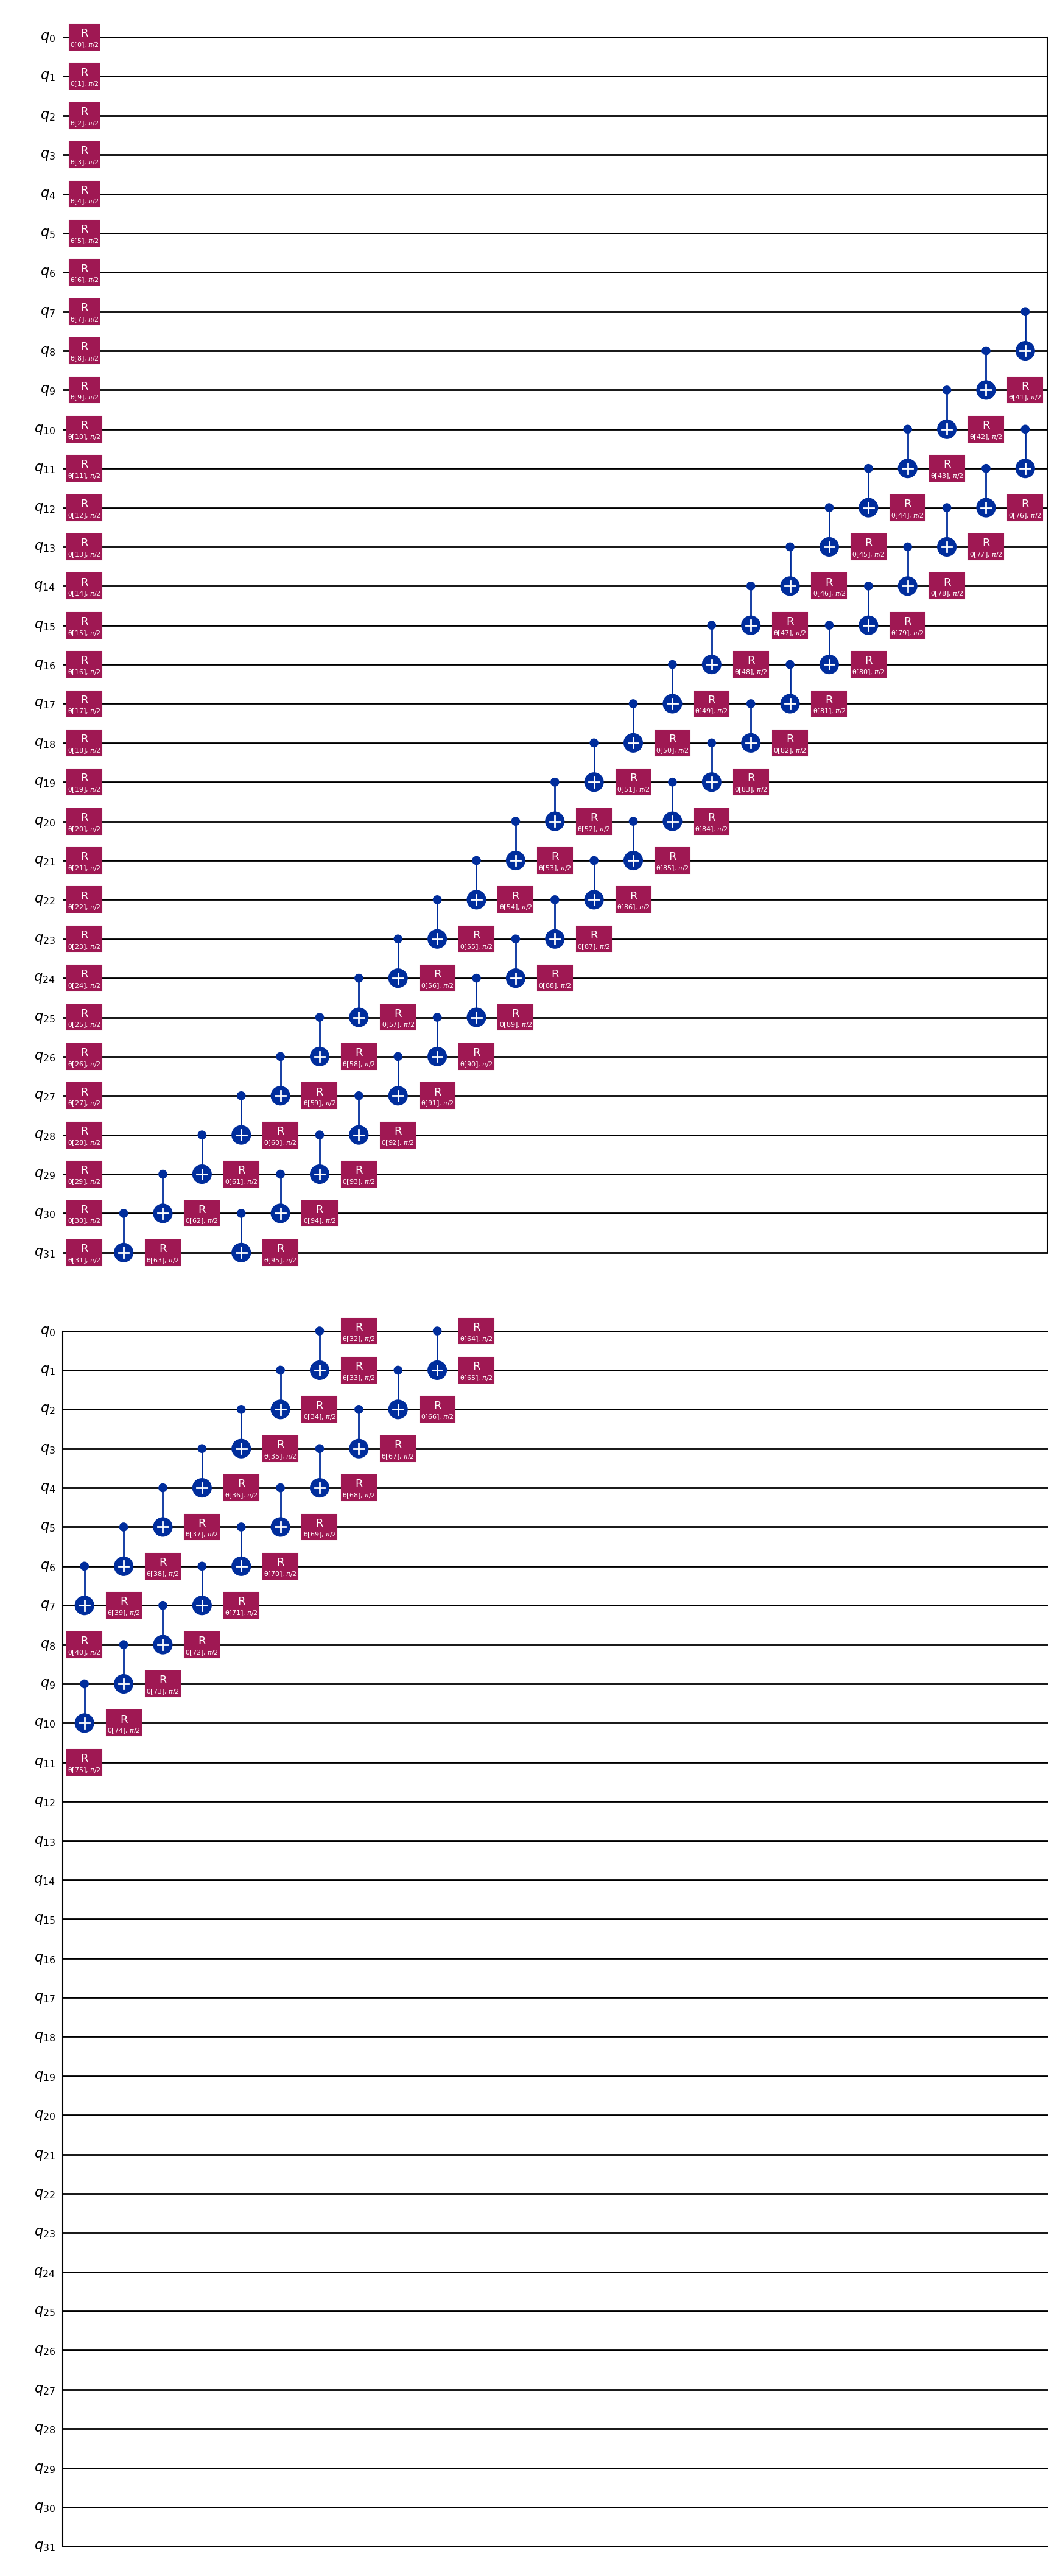

In [12]:
## vqe

ansatz = real_amplitudes(qubitOp.num_qubits, reps=2)
ansatz.decompose().draw("mpl", style="iqp")

In [13]:
num_params = ansatz.num_parameters
num_params

96

In [14]:
def cost_func(params, ansatz, hamiltonian, estimator):
    """Return estimate of energy from estimator

    Parameters:
        params (ndarray): Array of ansatz parameters
        ansatz (QuantumCircuit): Parameterized ansatz circuit
        hamiltonian (SparsePauliOp): Operator representation of Hamiltonian
        estimator (EstimatorV2): Estimator primitive instance
        cost_history_dict: Dictionary for storing intermediate results

    Returns:
        float: Energy estimate
    """
    pub = (ansatz, [hamiltonian], [params])
    result = estimator.run(pubs=[pub]).result()
    energy = result[0].data.evs[0]

    cost_history_dict["iters"] += 1
    cost_history_dict["prev_vector"] = params
    cost_history_dict["cost_history"].append(energy)
    print(f"Iters. done: {cost_history_dict['iters']} [Current cost: {energy}]")

    return energy

In [15]:
x0 = 2 * np.pi * np.random.random(num_params)
x0

array([3.44155248, 6.08541346, 2.09514398, 0.1060952 , 5.84855412,
       2.26355537, 2.69949568, 2.84326307, 2.63745076, 3.10425139,
       3.4497245 , 5.47673638, 0.03473045, 5.23799379, 1.42266915,
       5.19341904, 2.50533891, 0.16467953, 0.87789028, 0.10554112,
       0.68398133, 5.33153729, 3.06206826, 1.07222865, 3.66296654,
       2.79857013, 1.01311908, 4.9589048 , 0.16617683, 2.96396276,
       1.87307523, 4.35226316, 5.41699716, 1.47358325, 1.22432597,
       3.90949488, 4.08108836, 0.1721233 , 3.01516421, 0.18040674,
       4.56074738, 0.24932999, 6.21509589, 3.93521743, 3.11168179,
       0.49370888, 3.83536522, 2.28337231, 3.5169076 , 6.23879992,
       1.24957239, 1.46216673, 4.96159102, 3.48965801, 3.63111661,
       1.09924445, 5.18968562, 3.12890049, 2.22826954, 4.20157895,
       4.68047389, 2.57016583, 4.30043571, 2.32327825, 5.16897215,
       2.79759777, 2.82850182, 2.29817609, 4.85543091, 3.75787813,
       0.13777598, 3.86428261, 5.76963162, 2.98956602, 1.48611

In [16]:
cost_history_dict = {
    "prev_vector": None,
    "iters": 0,
    "cost_history": [],
}

In [17]:
ansatz = ansatz.decompose()

res = minimize(
        cost_func,
        x0,
        args=(ansatz, qubitOp, estimator),
        method="cobyla",
    )

Iters. done: 1 [Current cost: -2300.839111328125]
Iters. done: 2 [Current cost: -1860.70703125]
Iters. done: 3 [Current cost: -1201.0927734375]
Iters. done: 4 [Current cost: -1755.155517578125]
Iters. done: 5 [Current cost: -2607.111328125]
Iters. done: 6 [Current cost: -3433.09521484375]
Iters. done: 7 [Current cost: -2960.55126953125]
Iters. done: 8 [Current cost: -3038.471923828125]
Iters. done: 9 [Current cost: -3048.382568359375]
Iters. done: 10 [Current cost: -2272.546630859375]
Iters. done: 11 [Current cost: -2619.940185546875]
Iters. done: 12 [Current cost: -3769.318603515625]
Iters. done: 13 [Current cost: -3898.754638671875]
Iters. done: 14 [Current cost: -4474.064697265625]
Iters. done: 15 [Current cost: -3261.807373046875]
Iters. done: 16 [Current cost: -4490.2333984375]
Iters. done: 17 [Current cost: -4346.21826171875]
Iters. done: 18 [Current cost: -4432.979736328125]
Iters. done: 19 [Current cost: -4720.320556640625]
Iters. done: 20 [Current cost: -5854.814208984375]
Ite

In [18]:
res

 message: Maximum number of function evaluations has been exceeded.
 success: False
  status: 2
     fun: -37526.848876953125
       x: [ 3.002e+00  5.046e+00 ...  2.020e+00  3.893e+00]
    nfev: 1000
   maxcv: 0.0

In [19]:
all(cost_history_dict["prev_vector"] == res.x)


False

In [20]:
cost_history_dict["iters"] == res.nfev

True

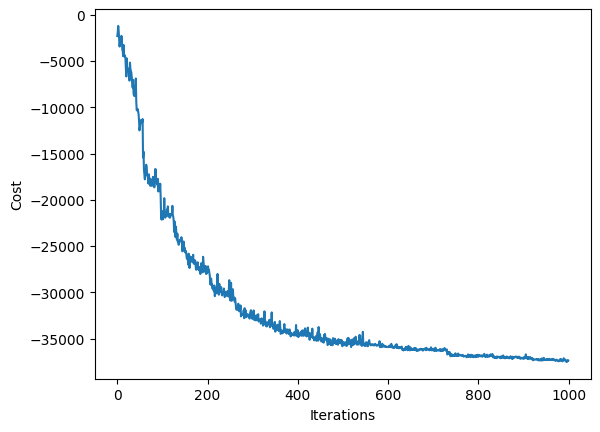

In [21]:
fig, ax = plt.subplots()
ax.plot(range(cost_history_dict["iters"]), cost_history_dict["cost_history"])
ax.set_xlabel("Iterations")
ax.set_ylabel("Cost")
plt.draw()

In [22]:
ansatz = ansatz.assign_parameters(res.x)

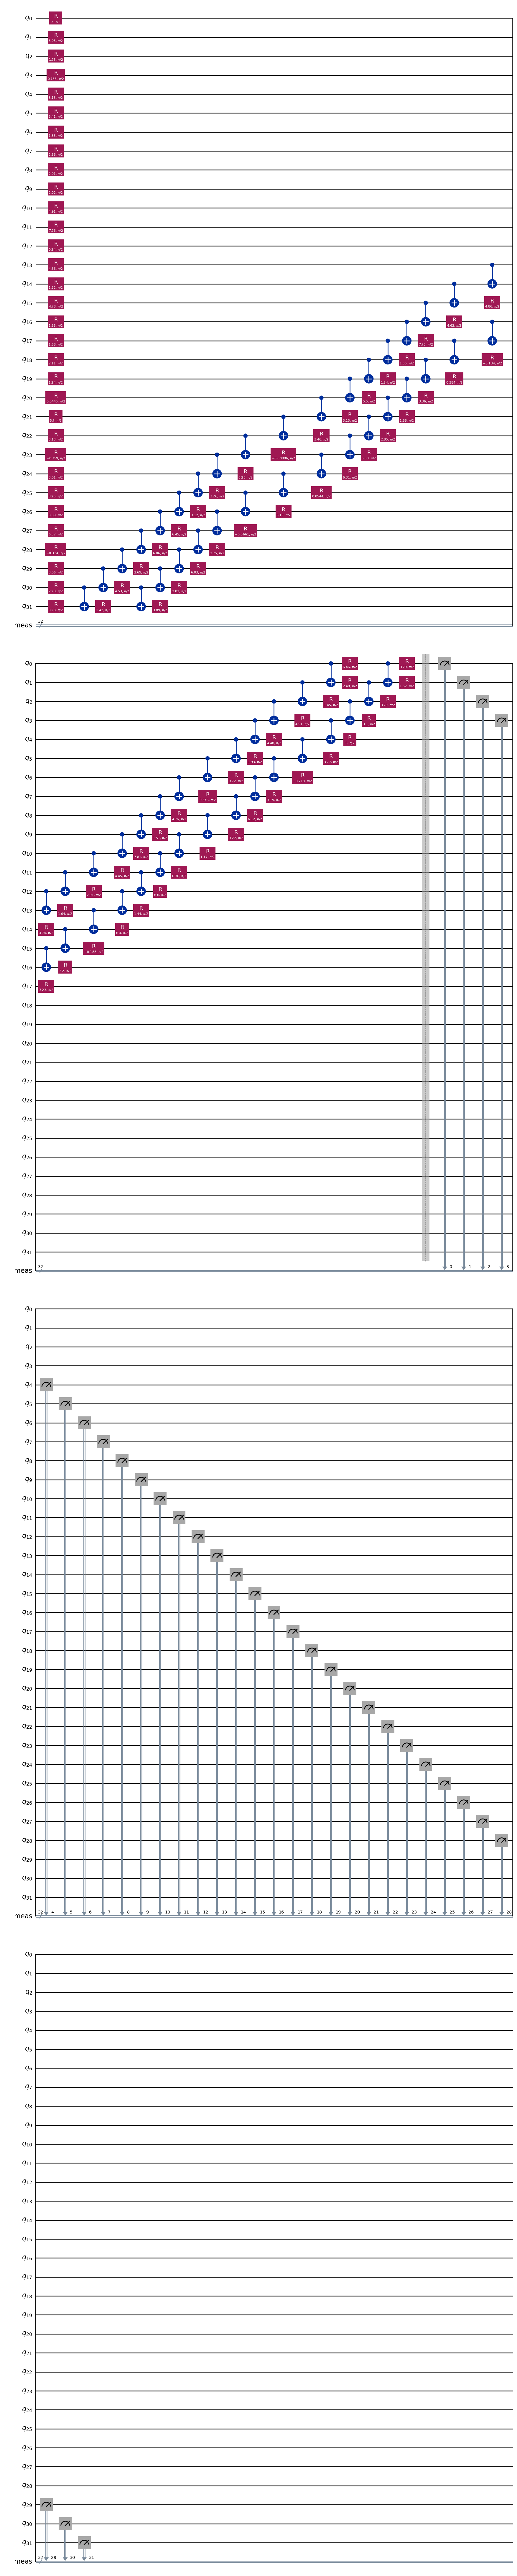

In [23]:
ansatz.measure_all()
ansatz.draw("mpl", style="iqp")

In [24]:
pub = (ansatz,)
job = sampler.run([pub], shots=int(1e4))
counts_int = job.result()[0].data.meas.get_int_counts()
counts_bin = job.result()[0].data.meas.get_counts()
shots = sum(counts_int.values())
final_distribution_int = {key: val/shots for key, val in counts_int.items()}
final_distribution_bin = {key: val/shots for key, val in counts_bin.items()}

In [25]:
# auxiliary functions to sample most likely bitstring
def to_bitstring(integer, num_bits):
    result = np.binary_repr(integer, width=num_bits)
    return [int(digit) for digit in result]

keys = list(final_distribution_int.keys())
values = list(final_distribution_int.values())
most_likely = keys[np.argmax(np.abs(values))]
most_likely_bitstring = to_bitstring(most_likely, num_nodes)
most_likely_bitstring.reverse()

print("Result bitstring:", most_likely_bitstring)

Result bitstring: [0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0]


In [26]:
solution = converter.interpret([int(b) for b in most_likely_bitstring])
cost = qp.objective.evaluate(solution)
feasible = qp.get_feasibility_info(solution)[0]
print(f"Solution: {solution}, Cost: {cost}, Feasible: {feasible}")


Solution: [0. 1. 0. 0. 0. 0. 0. 0. 1. 0. 1. 0. 1. 1. 0. 0. 0. 0. 0. 0. 0. 1. 0. 1.
 0. 0. 0. 0. 0. 0. 0. 0.], Cost: 7.0, Feasible: True
